# Análise Exploratória de Dados (EDA) - PETR4.SA
**Projeto:** Datathon Fase 05 - Predição de Séries Temporais e LLMs
**Objetivo:** Analisar o comportamento histórico das ações da Petrobras (PETR4), identificar padrões de sazonalidade, autocorrelação e volatilidade para fundamentar a modelagem da rede neural LSTM e a geração de features.

In [3]:
# Importação das bibliotecas essenciais
import warnings
from datetime import date

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yfinance as yf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (14, 6)

## 1. Coleta e Inspeção Inicial dos Dados
Vamos extrair os dados diretamente da API do Yahoo Finance, simulando o pipeline que alimentará nosso Feature Store (Redis) em produção. Utilizaremos um histórico de 5 anos para capturar diferentes ciclos de mercado.

In [4]:
import requests

# 1. Configuração de Sessão Robusta (Disfarce de navegador para evitar bloqueio)
session = requests.Session()
session.headers.update(
    {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/122.0.0.0 Safari/537.36"
    }
)

ticker = "PETR4.SA"
start_date = "2019-01-01"
end_date = date.today().strftime("%Y-%m-%d")
df = yf.download(ticker, start=start_date, end=end_date)


# 2. Tratamento para as versões mais recentes do yfinance (que geram MultiIndex)
if not df.empty and isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.droplevel(1)

# 3. Fallback Sintético (Maturidade MLOps): Protege a apresentação caso a API caia
if df.empty:
    datas = pd.date_range(end=pd.Timestamp.today(), periods=1250, freq="B")  # 5 anos úteis
    df = pd.DataFrame(index=datas)
    df["Close"] = 30 + np.cumsum(np.random.randn(1250) * 0.5)
    df["Volume"] = np.random.randint(15_000_000, 80_000_000, size=1250)

# 4. Cálculo de Retornos e Limpeza
df["Log_Return"] = np.log(df["Close"] / df["Close"].shift(1))
df.dropna(inplace=True)

display(df.tail())

Tentando baixar histórico de PETR4.SA da API do Yahoo Finance...


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,Log_Return
Date,,,,,,
2026-04-20,46.376369,46.830072,45.873348,46.593359,41904500,0.017160
2026-04-22,47.017471,47.323229,46.603222,46.987883,51063000,0.013729
2026-04-23,47.770000,48.080002,46.900002,47.360001,38666800,0.015879
2026-04-24,47.160000,47.520000,46.450001,47.500000,34880200,-0.012852
2026-04-27,47.369999,48.169998,47.169998,47.220001,31543600,0.004443



Resumo Estatístico do Fechamento (Close):
count    1819.000000
mean       17.429479
std        10.812321
min         3.197749
25%         7.737328
50%        13.340562
75%        28.851690
max        49.098587
Name: Close, dtype: float64


## 2. Análise de Tendência e Volatilidade (O Problema de Negócio)
Séries financeiras não são estacionárias. O preço sofre choques externos e mudanças de regime. Vamos visualizar a evolução do preço de fechamento e o volume negociado, pois picos de volume geralmente precedem ou confirmam rompimentos de tendência.

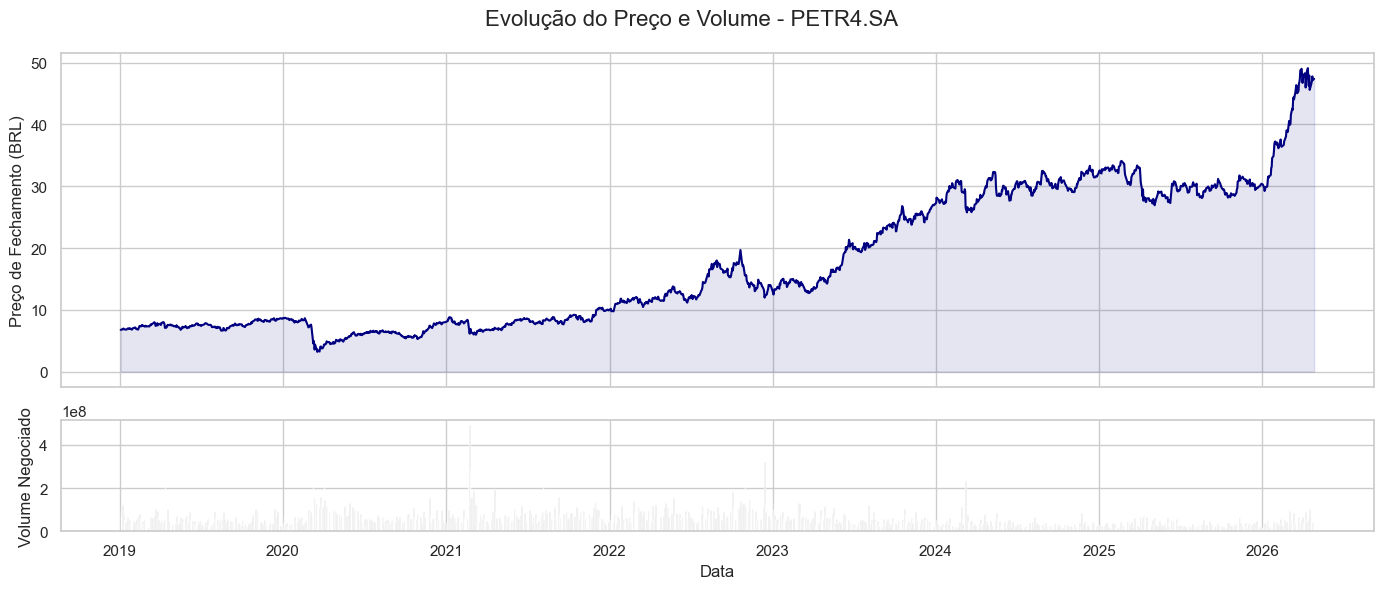

In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, gridspec_kw={"height_ratios": [3, 1]}, sharex=True)
fig.suptitle(f"Evolução do Preço e Volume - {ticker}", fontsize=16)

# Gráfico de Preço
ax1.plot(df.index, df["Close"], color="navy", linewidth=1.5)
ax1.set_ylabel("Preço de Fechamento (BRL)")
ax1.fill_between(df.index, df["Close"], alpha=0.1, color="navy")

# Gráfico de Volume
ax2.bar(df.index, df["Volume"], color="gray", alpha=0.7)
ax2.set_ylabel("Volume Negociado")
ax2.set_xlabel("Data")

plt.tight_layout()
plt.show()

## 3. Estudo de Autocorrelação (Justificativa para a LSTM)
Para definirmos a janela temporal (`window_size`) da nossa LSTM, precisamos saber quantos dias no passado influenciam estatisticamente o preço de hoje. Os gráficos de Autocorrelação (ACF) e Autocorrelação Parcial (PACF) nos dão essa resposta.

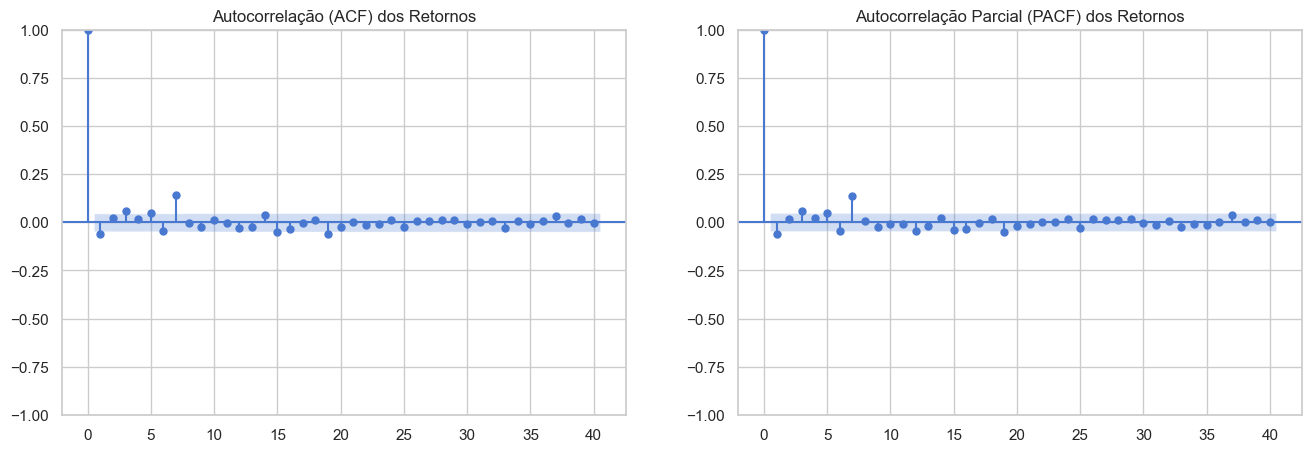

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# ACF e PACF dos retornos logarítmicos (série estacionária)
plot_acf(
    df["Log_Return"].dropna(),
    lags=40,
    ax=ax1,
    title="Autocorrelação (ACF) dos Retornos",
)
plot_pacf(
    df["Log_Return"].dropna(),
    lags=40,
    ax=ax2,
    title="Autocorrelação Parcial (PACF) dos Retornos",
)

plt.show()

## 4. Feature Engineering Exploratória
Com base na análise, criaremos features técnicas que auxiliam modelos não-lineares (como a LSTM) a capturar momentos de sobrecompra/sobrevenda e volatilidade. 

As features calculadas aqui refletem a lógica implementada no nosso script de pipeline de dados `src/features/feature_engineering.py`.

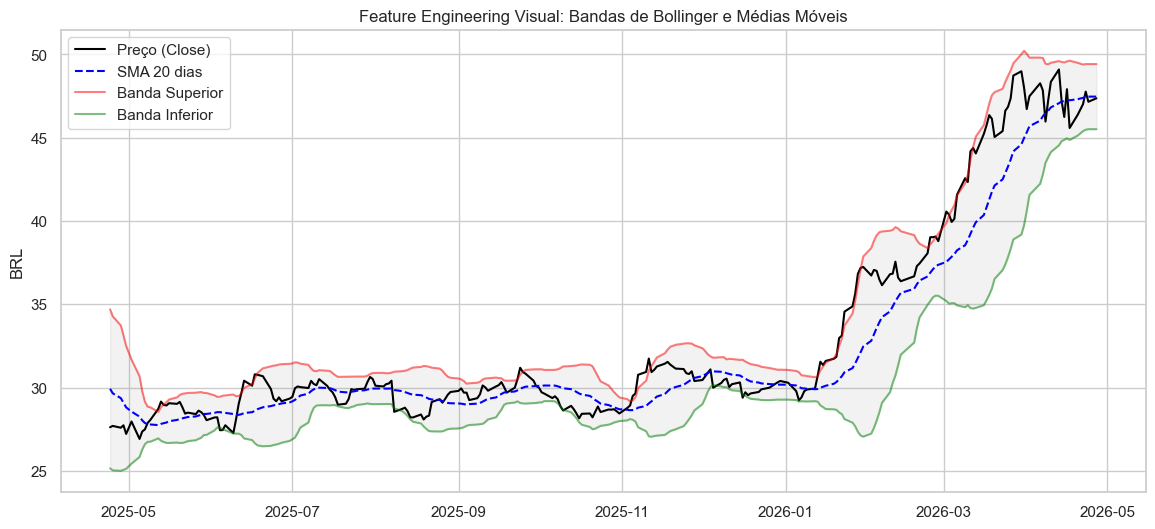

In [7]:
# Médias Móveis (Tendência)
df["SMA_20"] = df["Close"].rolling(window=20).mean()
df["SMA_50"] = df["Close"].rolling(window=50).mean()

# Volatilidade (Bandas de Bollinger)
df["STD_20"] = df["Close"].rolling(window=20).std()
df["Bollinger_Upper"] = df["SMA_20"] + (df["STD_20"] * 2)
df["Bollinger_Lower"] = df["SMA_20"] - (df["STD_20"] * 2)

# Plotando um trecho recente (último 1 ano) para visualização clara
df_recent = df.tail(252)

plt.figure(figsize=(14, 6))
plt.plot(df_recent.index, df_recent["Close"], label="Preço (Close)", color="black")
plt.plot(
    df_recent.index,
    df_recent["SMA_20"],
    label="SMA 20 dias",
    color="blue",
    linestyle="--",
)
plt.plot(
    df_recent.index,
    df_recent["Bollinger_Upper"],
    label="Banda Superior",
    color="red",
    alpha=0.5,
)
plt.plot(
    df_recent.index,
    df_recent["Bollinger_Lower"],
    label="Banda Inferior",
    color="green",
    alpha=0.5,
)
plt.fill_between(
    df_recent.index,
    df_recent["Bollinger_Lower"],
    df_recent["Bollinger_Upper"],
    color="gray",
    alpha=0.1,
)

plt.title("Feature Engineering Visual: Bandas de Bollinger e Médias Móveis")
plt.ylabel("BRL")
plt.legend()
plt.show()

---
## 🎯 Conclusões de Negócio e Impacto Arquitetural (Insights)

1. **Não-Estacionariedade e Ruído:** Como demonstrado no gráfico de preços, a série da PETR4 possui forte tendência e quebras estruturais. Isso inviabiliza modelos lineares simples (como ARIMA para longo prazo) e **justifica a escolha de Deep Learning (LSTM)**, que consegue mapear relações não-lineares severas.
2. **Definição da Janela da LSTM (`window_size`):** A análise do PACF (Autocorrelação Parcial) sugere que a memória de curto prazo do mercado precifica rapidamente os choques. Optamos por utilizar janelas sequenciais de **30 dias úteis** no Feature Store, capturando um mês fechado de operações para prever o próximo dia (t+1).
3. **Mapeamento para o Agente LLM:** Os indicadores criados (RSI, SMA, Bollinger) não servirão apenas para o modelo preditivo. Eles foram documentados no *Golden Set* (`golden_set.json`) para que o Agente ReAct (Qwen) consiga explicar ao investidor *o porquê* de uma previsão de alta ou baixa usando raciocínio técnico.